# Portfolio Code 

In [12]:
# Libraries 

import json
import os
import pathlib

import earthpy
import hvplot.xarray
import rioxarray as rxr
import xarray as xr

import geopandas as gpd
import hvplot.pandas

from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

### open street map
from osmnx import features as osm
import osmnx as ox


<Axes: >

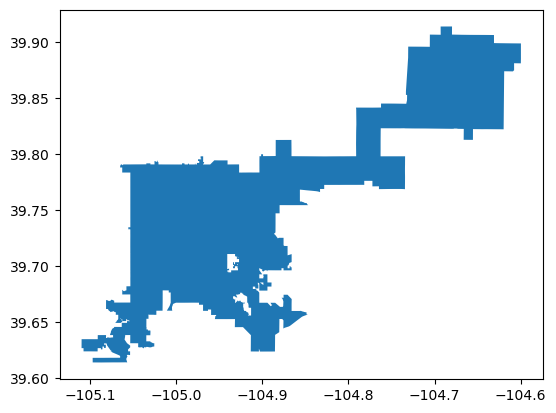

In [21]:
boulder_county_gdf = ox.geocode_to_gdf(
    'Denver, Colorado, United States')

boulder_county_gdf

boulder_county_gdf.plot()

In [4]:
# NDVI 
project = earthpy.Project(dirname='boulder_county_ndvi')

# Get a sorted list of NDVI tif file paths
ndvi_paths = sorted(list(project.project_dir.rglob('MOD13Q1.061__250m_16_days_NDVI*.tif')))

# Display the first and last three files paths to check the pattern
ndvi_paths[:3], ndvi_paths[-3:]

([PosixPath('/workspaces/data/boulder_county_ndvi/boulder_county_ndvi/MOD13Q1.061_2020107_to_2022212/MOD13Q1.061__250m_16_days_NDVI_doy2020113000000_aid0001.tif'),
  PosixPath('/workspaces/data/boulder_county_ndvi/boulder_county_ndvi/MOD13Q1.061_2020107_to_2022212/MOD13Q1.061__250m_16_days_NDVI_doy2020129000000_aid0001.tif'),
  PosixPath('/workspaces/data/boulder_county_ndvi/boulder_county_ndvi/MOD13Q1.061_2020107_to_2022212/MOD13Q1.061__250m_16_days_NDVI_doy2020145000000_aid0001.tif')],
 [PosixPath('/workspaces/data/boulder_county_ndvi/boulder_county_ndvi/MOD13Q1.061_2020107_to_2022212/MOD13Q1.061__250m_16_days_NDVI_doy2022177000000_aid0001.tif'),
  PosixPath('/workspaces/data/boulder_county_ndvi/boulder_county_ndvi/MOD13Q1.061_2020107_to_2022212/MOD13Q1.061__250m_16_days_NDVI_doy2022193000000_aid0001.tif'),
  PosixPath('/workspaces/data/boulder_county_ndvi/boulder_county_ndvi/MOD13Q1.061_2020107_to_2022212/MOD13Q1.061__250m_16_days_NDVI_doy2022209000000_aid0001.tif')])

In [5]:

ndvi_das = []

for ndvi_path in ndvi_paths:
    # Get date from file name
    fname = ndvi_path.name  # just the filename, not the whole path
    # find the substring "doy" and take the next 7 digits (YYYYDDD)
    doy_index = fname.find("doy") + 3
    date_str = fname[doy_index:doy_index + 7]  # e.g. '2001145'
    year = int(date_str[:4])
    doy = int(date_str[4:])
    date = pd.to_datetime(f"{year}-{doy}", format="%Y-%j")
    
    # Open dataset
    da = rxr.open_rasterio(ndvi_path, masked=True).squeeze()
    
    # Add date dimension and clean up metadata 
    da = da.assign_coords({'date': date}).expand_dims({'date': [date]})
    da.name = 'NDVI'
    
    # Prepare for concatenation
    ndvi_das.append(da)

ndvi_da = xr.combine_by_coords(ndvi_das, coords=['date'])


/tmp/ipykernel_1226/3145327063.py:23: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das, coords=['date'])
/tmp/ipykernel_1226/3145327063.py:23: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ndvi_da = xr.combine_by_coords(ndvi_das, coords=['date'])


In [6]:
ndvi_da

<xarray.Dataset> Size: 4MB
Dimensions:      (date: 21, y: 169, x: 309)
Coordinates:
  * date         (date) datetime64[ns] 168B 2020-04-22 2020-05-08 ... 2022-07-28
    band         int64 8B 1
  * x            (x) float64 2kB -105.7 -105.7 -105.7 ... -105.1 -105.1 -105.1
  * y            (y) float64 1kB 40.26 40.26 40.26 40.26 ... 39.92 39.92 39.91
    spatial_ref  int64 8B 0
Data variables:
    NDVI         (date, y, x) float32 4MB -163.0 -282.0 ... 3.29e+03 3.29e+03

In [7]:
# 2001–2011 
ndvi_2020 = ndvi_da.sel(date=slice('2020'))

# temporal mean
ndvi_2020 = ndvi_2020.mean(dim='date')

# 2012–2022 
ndvi_2021 = ndvi_da.sel(date=slice('2021'))

# temporal mean 
ndvi_2021 = ndvi_2021.mean(dim='date')

# 2012–2022 
ndvi_2022 = ndvi_da.sel(date=slice('2022'))

# temporal mean 
ndvi_2022 = ndvi_2022.mean(dim='date')



# Compute the difference in NDVI before and after
ndvi_diff_2022_2020 = ndvi_2022 - ndvi_2020

ndvi_diff_2022_2021 = ndvi_2022 - ndvi_2021

ndvi_diff_2021_2020 = ndvi_2021 - ndvi_2020


# save as data array
ndvi_diff_da_2022_2020 = ndvi_diff_2022_2020['NDVI']

ndvi_diff_da_2022_2021 = ndvi_diff_2022_2021['NDVI']

ndvi_diff_da_2021_2020 = ndvi_diff_2021_2020['NDVI']

In [15]:
# scale NDVI first 
ndvi_diff_scaled = ndvi_diff_da_2022_2020 * 0.0001

(
    ndvi_diff_scaled.hvplot(x='x', y='y', cmap='PiYG', geo=True, 
                            title='Difference in NVDI from the 2020 to 2022', ylabel='Latitude', xlabel='Longitude')
    *
    boulder_county_gdf.hvplot(geo=True, fill_color=None, line_color='black') # add boundary
)

:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]

In [20]:
ndvi_2020_scaled = ndvi_2020 * 0.0001
ndvi_2020_scaled.hvplot(x='x', y='y', geo = True) * boulder_county_gdf.hvplot(geo=True, fill_color=None, line_color='black') # add boundary


:Overlay
   .Image.I    :Image   [x,y]   (NDVI)
   .Polygons.I :Polygons   [Longitude,Latitude]